<a href="https://colab.research.google.com/github/Vaness09/mne_meeg_ml_main/blob/main/1-plot_meeg_data_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNE-Python: From raw data to epochs and evoked responses (ERF/ERP)

`Code source : Alexandre Gramfort, Denis A. Engemann, Jona Sassenhagen and Richard Höchenberger
 Modified by Annalisa Pascarella, Vanessa Hadid`

In [4]:
!git clone https://github.com/thecocolab/mne_meeg_ml_main.git

Cloning into 'mne_meeg_ml_main'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 67 (delta 30), reused 43 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 12.34 MiB | 31.05 MiB/s, done.
Resolving deltas: 100% (30/30), done.


This line of code uses !git clone to download a Git repository from the specified URL: https://github.com/thecocolab/mne_meeg_ml_main.git. This command effectively copies the entire project, including all its files and version history, from GitHub to your current Colab environment. This is a common first step when working with external code or datasets hosted on GitHub.

In [5]:
%cd mne_meeg_ml_main

/content/mne_meeg_ml_main


This line of code uses the IPython magic command %cd, which stands for 'change directory'. It changes the current working directory of your Colab environment to mne_meeg_ml_main. This is often done after cloning a Git repository to navigate into the newly downloaded project folder, allowing subsequent commands to operate within that directory.

In [6]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


This line of code uses the shell command !pip install -r requirements.txt to install all the Python libraries listed in the requirements.txt file. The -r flag tells pip to install packages from the specified file. This is a common way to ensure that all necessary dependencies for a project are installed in your environment.

In [4]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

This code cell imports several essential Python libraries that are commonly used in data analysis and scientific computing. Specifically: import os imports the operating system module, which allows you to interact with the operating system, for example, to handle file paths. import numpy as np imports NumPy, which is fundamental for numerical operations, especially with arrays and matrices. import matplotlib as mpl imports Matplotlib, a comprehensive library for creating static, animated, and interactive visualizations in Python. Finally, import matplotlib.pyplot as plt imports the pyplot module from Matplotlib, providing a MATLAB-like interface for plotting functions.

## Load the mne package


In [1]:
import mne
print(mne.__version__)

1.12.1


This code cell performs two main actions: First, import mne imports the MNE-Python library, which is a powerful tool for analyzing electrophysiological data like MEG and EEG. Second, print(mne.__version__) displays the version number of the MNE-Python library that is currently installed in your environment. In this case, it printed 1.12.1.

We set the logging level to 'warning' so the output will be less verbose

In [2]:
mne.set_log_level('warning')

This line of code, mne.set_log_level('warning'), sets the logging level for the MNE-Python library to 'warning'. This means that MNE will only display messages that are warnings, errors, or critical messages, and will suppress less important informational messages. This is often done to make the output less verbose and focus on potential issues.

## Download sample dataset

Now we import the [`sample`](https://mne.tools/stable/documentation/datasets.html#sample-dataset) dataset. It will be downloaded automatically (approx. 2 GB).

In [7]:
from mne.datasets import sample
data_path = sample.data_path()

raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif')
print(raw_fname)

/root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif


This code cell is responsible for setting up the path to a sample MNE-Python dataset. First, from mne.datasets import sample imports the sample module, which provides access to a standard dataset for MNE-Python. Then, data_path = sample.data_path() retrieves the directory where this sample dataset is located or downloads it if it's not already present. Finally, raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif') constructs the full file path to a specific raw MEG (Magnetoencephalography) data file within that dataset, named 'sample_audvis_filt-0-40_raw.fif'. The last line, print(raw_fname), simply displays this constructed file path, which in your case is /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif.

This example uses a .fif MEG file, but MNE-Python can load many electrophysiological formats from different acquisition systems.

Common supported formats include:

EEG	.edf, .bdf, .vhdr, .set
MEG	.fif, .ds, .con
Intracranial EEG (iEEG/ECoG/SEEG)	.edf, .fif
Sleep recordings	.edf
BrainVision	.vhdr
EEGLAB	.set
BioSemi	.bdf

Different formats are loaded using different MNE functions.

mne.io.read_raw_fif()
Loads FIF MEG/EEG files.

mne.io.read_raw_edf()
Loads EDF EEG recordings.

mne.io.read_raw_brainvision()
Loads BrainVision EEG data.

mne.io.read_raw_eeglab()
Loads EEGLAB datasets.

In addition to supporting many electrophysiological file formats, MNE-Python is also compatible with BIDS (Brain Imaging Data Structure), a standardized way of organizing neuroimaging and electrophysiological datasets. BIDS does not replace the original data format (such as .fif, .edf, or .vhdr), but instead defines a consistent folder structure, naming convention, and metadata organization across subjects and experiments. This standardization facilitates data sharing, reproducibility, and automated analysis pipelines. MNE-Python can interact with BIDS datasets using the mne-bids package, which allows users to efficiently load and manage large EEG/MEG datasets across multiple participants and sessions.

from mne_bids import BIDSPath, read_raw_bids

## Read data from file

To see what a function does...use this notation!

This code, mne.io.read_raw_fif?, is an IPython feature (specific to environments like Colab or Jupyter notebooks) that allows you to quickly view the documentation (docstring) and signature of a Python object, in this case, the read_raw_fif function from the mne.io module. This function is used to read raw MEG/EEG data files in the FIF (fiff) format.


In [9]:
mne.io.read_raw_fif?

mne.io.read_raw_fif(
    fname,
    allow_maxshield=False,
    preload=False,
    on_split_missing='raise',
    verbose=None,
) -> mne.io.fiff.raw.Raw

fname: This parameter corresponds to the path of the electrophysiological recording we want to open. In other words, it tells MNE where the raw EEG or MEG file is located on the computer.

allow_maxshield=False: This parameter is specific to some MEG acquisition systems that use an internal noise compensation method called MaxShield. Think of this as a safety option for special MEG acquisition modes.

preload=False: This parameter determines whether the electrophysiological data are immediately loaded into memory. If preload=True, the entire recording is loaded into RAM, which makes later processing faster but uses more memory. If False, the data stay mostly on disk and are loaded only when needed. For large EEG or MEG datasets, memory management becomes very important.

on_split_missing='raise': Some very large MEG recordings are automatically divided into multiple files during acquisition. This parameter tells MNE what to do if one of the split files is missing.

verbose=None: This parameter controls how much information MNE prints during execution.For example: warnings, loading progress, preprocessing messages, debugging information.

Return Value: This means the function returns a Raw object. The Raw object is one of the central data structures in MNE-Python. It contains: the electrophysiological signals, channel names, timing information, sensor metadata, acquisition information. This object then becomes the starting point for preprocessing and analysis.

It creates a Python object representing the electrophysiological recording inside memory.

In [10]:
raw = mne.io.read_raw_fif(raw_fname, preload=True)
print(raw)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>


If `preload=True` data will be preloaded into memory for data manipulation and faster indexing (requires large amount of memory). By default, the data will not be loaded into memory.
    
Printing the [`Raw`](https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw) object displays some basic information like the total number of channels, the number of time points at which the data were sampled, total duration, and the approximate size in memory.


Now let's take a look at the measurement info stored in the `raw.info` attribute.  It will provide details about:

   - sampling rate
   - filtering parameters
   - available channel types
   - bad channels
   - etc.

Here it shows that 376 channels and 41700 time points were loaded, covering 277.7 seconds of data, and taking up about 122.9 MiB of memory, with the data already loaded into RAM.


In [11]:
print(raw.info)

<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


`raw.info` is just a dictionary and like Python dictionaries has a `.keys()` method that shows all the available field names

displays the measurement information (metadata) associated with the raw object. The output provides a summary of the loaded dataset, including key details such as the number of channels, their types (e.g., Gradiometers, Magnetometers, EEG, EOG), sampling frequency (sfreq), applied high-pass (highpass) and low-pass (lowpass) filter settings, any channels marked as 'bad' (bads), the measurement date (meas_date), and other acquisition parameters. This information is crucial for understanding the characteristics of your electrophysiological data.

In [12]:
isinstance(raw.info, dict)
print(raw.info.keys())

dict_keys(['file_id', 'events', 'hpi_results', 'hpi_meas', 'subject_info', 'device_info', 'helium_info', 'hpi_subsystem', 'proc_history', 'meas_id', 'experimenter', 'description', 'proj_id', 'proj_name', 'meas_date', 'utc_offset', 'sfreq', 'highpass', 'lowpass', 'line_freq', 'gantry_angle', 'chs', 'dev_head_t', 'ctf_head_t', 'dev_ctf_t', 'dig', 'bads', 'ch_names', 'nchan', 'projs', 'comps', 'acq_pars', 'acq_stim', 'custom_ref_applied', 'xplotter_layout', 'kit_system_id'])


This code cell performs two actions. First, isinstance(raw.info, dict) checks if the raw.info object is an instance of a Python dictionary. This confirms that raw.info behaves like a dictionary, allowing you to access its contents using keys. Second, print(raw.info.keys()) then displays all the available keys or field names within the raw.info dictionary. These keys represent different types of metadata stored about your MNE Raw object, such as sampling frequency, channel names, bad channels, and other acquisition details.

So we can access its elements this way:

By using ['sfreq'], you are retrieving the sampling frequency of your data, which is the number of data points acquired per second. In this case, it returned 150.15374755859375 Hz.

This line of code, raw.info['bads'], retrieves the list of channels that have been marked as 'bad' in your MNE Raw object. These are channels that might have been noisy or malfunctioning during data acquisition. Bad channels correspond to sensors or electrodes that were considered unreliable during acquisition or preprocessing due to excessive noise, poor signal quality, hardware issues, or artifacts. In this example, the channels MEG 2443 and EEG 053 were identified as problematic. Importantly, marking channels as bad does not remove them from the dataset; instead, MNE keeps track of them so that later preprocessing and analysis steps can ignore or interpolate them automatically. Identifying bad channels is an important part of electrophysiological data quality control, as noisy sensors can strongly affect downstream analyses such as averaging, ICA, source localization, and machine learning.

In [13]:
raw.info['sfreq']  # Sampling frequency

150.15374755859375

In [14]:
raw.info['bads']  # list of marked bad channels

['MEG 2443', 'EEG 053']

Looking at the info dict we observe that data were already filtered.

Now, let's see what channels are present in the data. We simply have to take a loot at the `raw.ch_names` attribute.

In [15]:
raw.ch_names

['MEG 0113',
 'MEG 0112',
 'MEG 0111',
 'MEG 0122',
 'MEG 0123',
 'MEG 0121',
 'MEG 0132',
 'MEG 0133',
 'MEG 0131',
 'MEG 0143',
 'MEG 0142',
 'MEG 0141',
 'MEG 0213',
 'MEG 0212',
 'MEG 0211',
 'MEG 0222',
 'MEG 0223',
 'MEG 0221',
 'MEG 0232',
 'MEG 0233',
 'MEG 0231',
 'MEG 0243',
 'MEG 0242',
 'MEG 0241',
 'MEG 0313',
 'MEG 0312',
 'MEG 0311',
 'MEG 0322',
 'MEG 0323',
 'MEG 0321',
 'MEG 0333',
 'MEG 0332',
 'MEG 0331',
 'MEG 0343',
 'MEG 0342',
 'MEG 0341',
 'MEG 0413',
 'MEG 0412',
 'MEG 0411',
 'MEG 0422',
 'MEG 0423',
 'MEG 0421',
 'MEG 0432',
 'MEG 0433',
 'MEG 0431',
 'MEG 0443',
 'MEG 0442',
 'MEG 0441',
 'MEG 0513',
 'MEG 0512',
 'MEG 0511',
 'MEG 0523',
 'MEG 0522',
 'MEG 0521',
 'MEG 0532',
 'MEG 0533',
 'MEG 0531',
 'MEG 0542',
 'MEG 0543',
 'MEG 0541',
 'MEG 0613',
 'MEG 0612',
 'MEG 0611',
 'MEG 0622',
 'MEG 0623',
 'MEG 0621',
 'MEG 0633',
 'MEG 0632',
 'MEG 0631',
 'MEG 0642',
 'MEG 0643',
 'MEG 0641',
 'MEG 0713',
 'MEG 0712',
 'MEG 0711',
 'MEG 0723',
 'MEG 0722',

You can index it as a list

In [16]:
raw.ch_names[42]

'MEG 0432'

In [17]:
raw.ch_names[:10]

['MEG 0113',
 'MEG 0112',
 'MEG 0111',
 'MEG 0122',
 'MEG 0123',
 'MEG 0121',
 'MEG 0132',
 'MEG 0133',
 'MEG 0131',
 'MEG 0143']

Channel type of a specific channel

Magnetometers measure the magnetic field itself, whereas gradiometers measure how the magnetic field changes across space. Gradiometers are generally more robust to environmental noise because they compare nearby measurements rather than measuring the absolute field alone.

In [20]:
mne.channel_type?

In [ ]:
channel_type = mne.channel_type(info=raw.info, idx=75)
print('Channel #75 is of type:', channel_type)

channel_type = mne.channel_type(info=raw.info, idx=320)
print('Channel #320 is of type:', channel_type)

Channel #75 is of type: grad
Channel #320 is of type: eeg


`raw.info['chs']` contains all the details about the sensors (type, locations, coordinate frame etc.)

In [21]:
len(raw.info['chs'])

376

In [22]:
type(raw.info['chs'])

list

In [23]:
raw.info['chs'][0]

{'scanno': 1,
 'logno': 113,
 'kind': 1 (FIFFV_MEG_CH),
 'range': 1.0,
 'cal': 3.1600000394149674e-09,
 'coil_type': 3012 (FIFFV_COIL_VV_PLANAR_T1),
 'loc': array([-0.1066    ,  0.0464    , -0.0604    , -0.0127    ,  0.0057    ,
        -0.99990302, -0.186801  , -0.98240298, -0.0033    , -0.98232698,
         0.18674099,  0.013541  ]),
 'unit': 201 (FIFF_UNIT_T_M),
 'unit_mul': 0 (FIFF_UNITM_NONE),
 'ch_name': 'MEG 0113',
 'coord_frame': 1 (FIFFV_COORD_DEVICE)}

Electrophysiological recordings are not just signal amplitudes over time. MNE also stores rich metadata about the sensors themselves, including their type, position, orientation, and acquisition properties. This metadata is essential for visualization, preprocessing, and source reconstruction

In [ ]:
raw.info['chs'][330]

{'scanno': 331,
 'logno': 16,
 'kind': 2 (FIFFV_EEG_CH),
 'range': 1.0,
 'cal': 0.0001875000016298145,
 'coil_type': 1 (FIFFV_COIL_EEG),
 'loc': array([ 0.06725728,  0.05876905,  0.0723644 ,  0.00235201,  0.11096951,
        -0.03500458,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ]),
 'unit': 107 (FIFF_UNIT_V),
 'unit_mul': 0 (FIFF_UNITM_NONE),
 'ch_name': 'EEG 016',
 'coord_frame': 4 (FIFFV_COORD_HEAD)}

It is possible to rename channels using the [`rename_channels()`](https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.rename_channels) method

In [24]:
raw.rename_channels({"EOG 061": "blink detector"})

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

To visualize the sensor locations we can use [`plot_sensors()`](https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.plot_sensors) method.

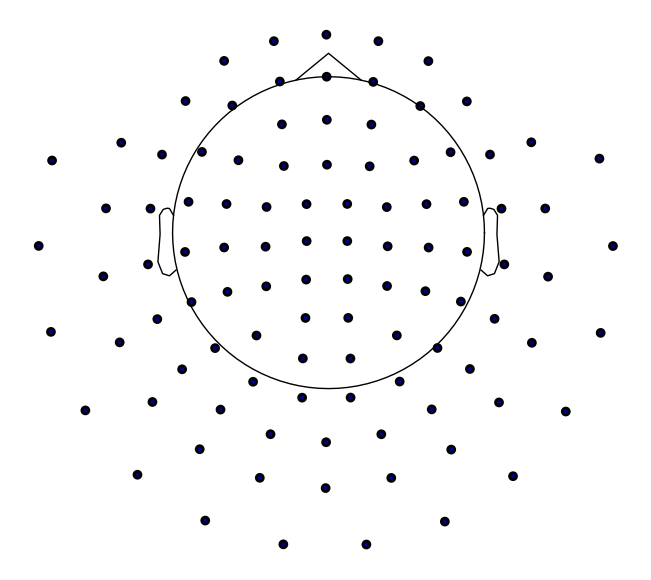

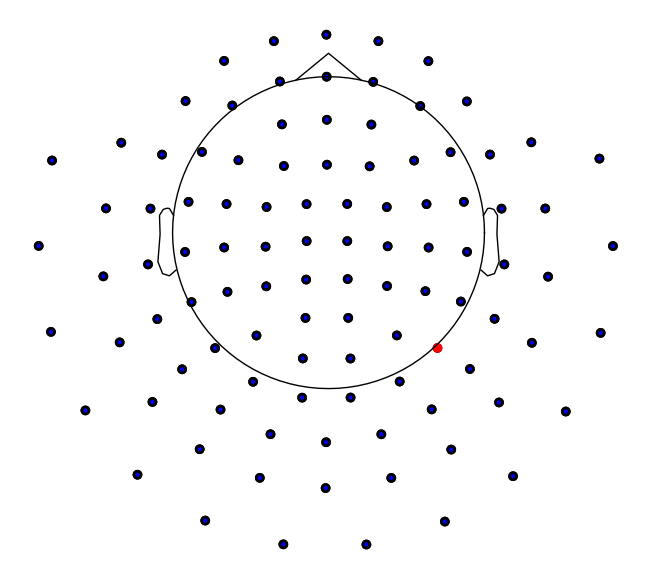

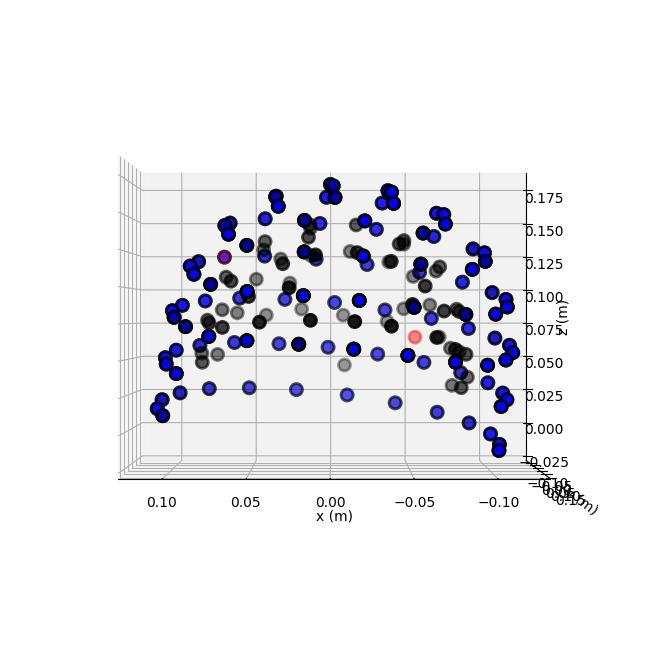

In [29]:
%matplotlib inline
raw.plot_sensors(kind='topomap', ch_type='mag');  # default topomap
raw.plot_sensors(ch_type='grad');
raw.plot_sensors(kind="3d", ch_type="all");

The [Working with sensor locations](https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html#sphx-glr-auto-tutorials-intro-40-sensor-locations-py) tutorial describes how to read and plot sensor locations, and how MNE-Python handles physical locations of sensors.

# Extracting data from `Raw` objects

To access the data, just use the `[]` syntax as to access any element of a list, dict etc. MNE-Python also returns an array of times (in seconds) corresponding to the requested samples.

In [31]:
start, stop = 0, 10
data, times = raw[:, start:stop]  # fetch all channels and the first 10 time points
print(data.shape)
print(times.shape)

(376, 10)
(10,)


In [32]:
times  # in seconds

array([0.        , 0.00665984, 0.01331968, 0.01997952, 0.02663936,
       0.0332992 , 0.03995904, 0.04661888, 0.05327872, 0.05993856])

To extract data in a given time window

In [33]:
sampling_freq = raw.info["sfreq"]
start_stop_seconds = np.array([11, 13])
start_sample, stop_sample = (start_stop_seconds * sampling_freq).astype(int)
channel_index = 0
raw_selection = raw[channel_index, start_sample:stop_sample]
print(raw_selection)

(array([[-1.20292928e-11, -9.85012327e-12, -6.24618310e-12,
        -5.81858254e-12, -8.26709172e-12, -9.47390603e-12,
        -8.40260120e-12, -7.93950648e-12, -8.96571088e-12,
        -8.95602112e-12, -7.15093074e-12, -6.00786247e-12,
        -6.54294063e-12, -6.84192232e-12, -5.98871103e-12,
        -5.25860162e-12, -4.93539186e-12, -3.89230469e-12,
        -2.65788192e-12, -3.34004505e-12, -6.19225374e-12,
        -9.04604833e-12, -1.01161679e-11, -9.28920758e-12,
        -7.37394236e-12, -6.03751556e-12, -7.31197351e-12,
        -1.09924238e-11, -1.36405519e-11, -1.24221320e-11,
        -9.01332828e-12, -7.46900280e-12, -9.03368340e-12,
        -1.14004407e-11, -1.23697337e-11, -1.16285216e-11,
        -9.52985206e-12, -7.14492118e-12, -7.11247777e-12,
        -1.09266820e-11, -1.54418731e-11, -1.58643113e-11,
        -1.23587284e-11, -9.66064248e-12, -1.00467018e-11,
        -1.12617940e-11, -1.16725618e-11, -1.23317045e-11,
        -1.31183629e-11, -1.20719410e-11, -9.88306477e-

To get all data you can use the `get_data()` method

In [34]:
data = raw.get_data()
print(data.shape)

(376, 41700)


# Visualizing raw data

Note : we will use the QT backend from matplotlib that will open a separate window.

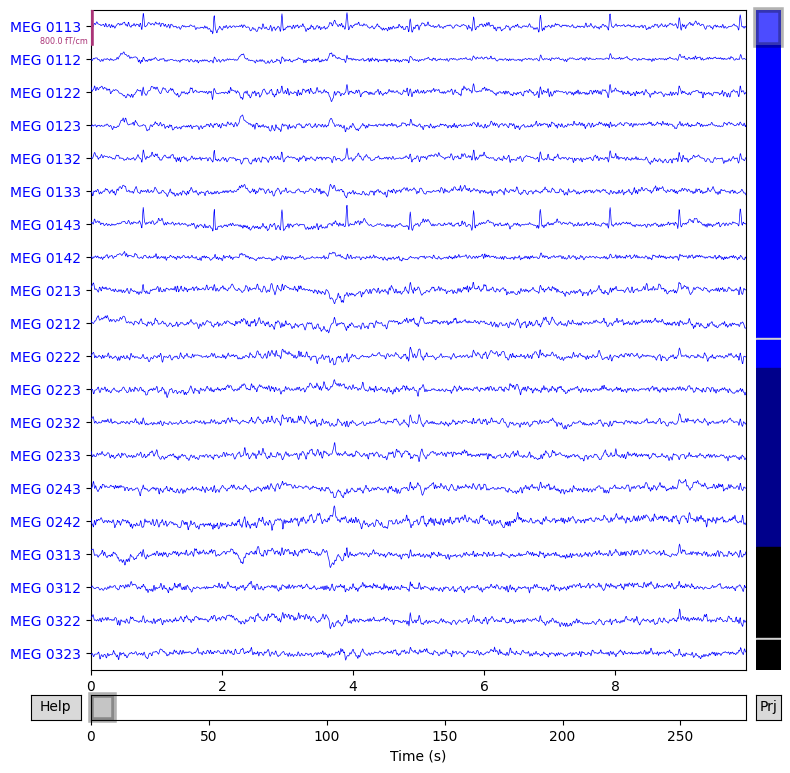

In [36]:
%matplotlib inline
fig = raw.plot()

In [ ]:
raw.info['bads']

['MEG 2443', 'EEG 053']

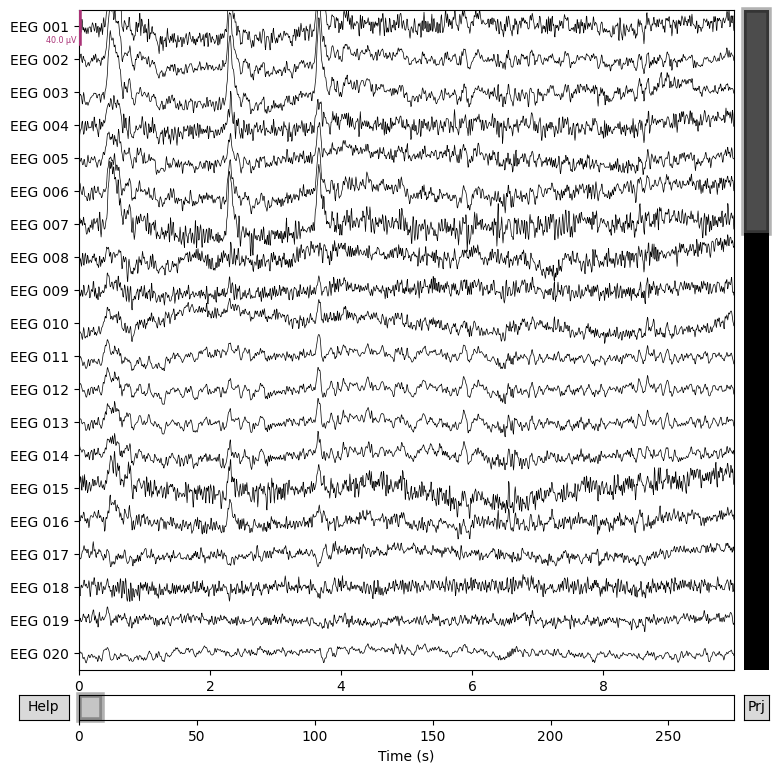

In [37]:
fig = raw.copy().pick_types(meg=False, eeg=True).plot() # to plot only EEG data

This code line fig = raw.copy().pick_types(meg=False, eeg=True).plot() first creates a copy of your raw MNE data object using .copy(). This is good practice to avoid modifying the original data. Then, .pick_types(meg=False, eeg=True) is used to select only the EEG channels, excluding MEG channels, for the subsequent operation. Finally, .plot() generates a visualization of the selected EEG data. The comment # to plot only EEG data accurately describes its purpose.

# Filtering

In [39]:
raw_beta = raw.copy().filter(l_freq=13, h_freq=30, verbose=True)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 153 samples (1.019 s)



This line of code, raw_beta = raw.copy().filter(l_freq=13, h_freq=30, verbose=True), performs several actions to filter your electrophysiological data. First, raw.copy() creates a duplicate of your original raw data object, ensuring that the original data is not modified. Then, .filter(l_freq=13, h_freq=30, verbose=True) applies a band-pass filter to this copied data. The l_freq=13 sets the lower frequency bound to 13 Hz, and h_freq=30 sets the upper frequency bound to 30 Hz, effectively isolating brain activity in the 'beta' frequency band. The verbose=True argument makes the filtering process more transparent by printing details about the filter's design and application. The resulting filtered data is stored in a new Raw object called raw_beta.

In [40]:
print(raw_beta.info)  # note the update of raw.info['lowpass'] and raw.info['highpass']

<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 13.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 30.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


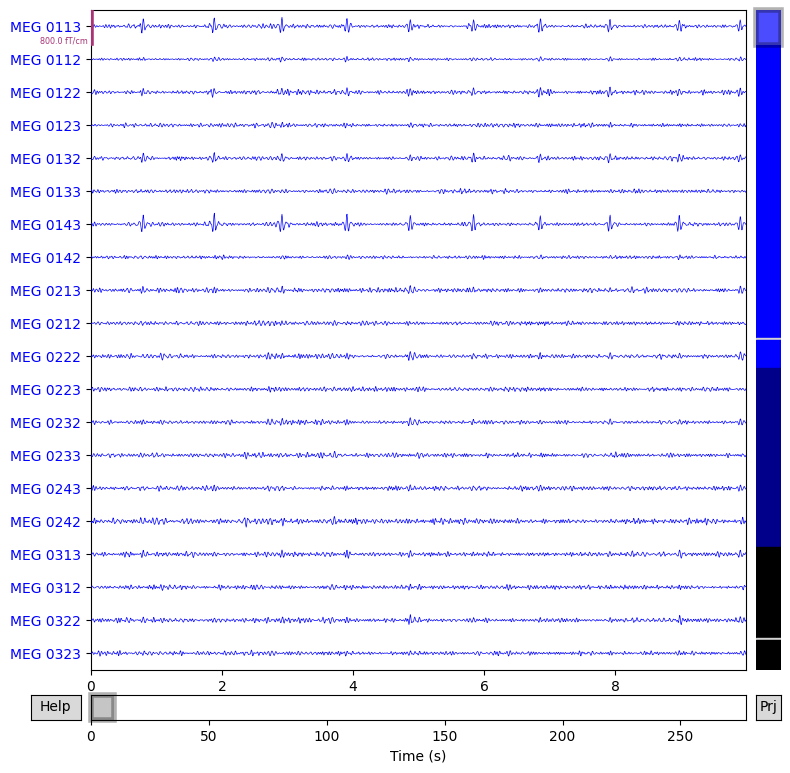

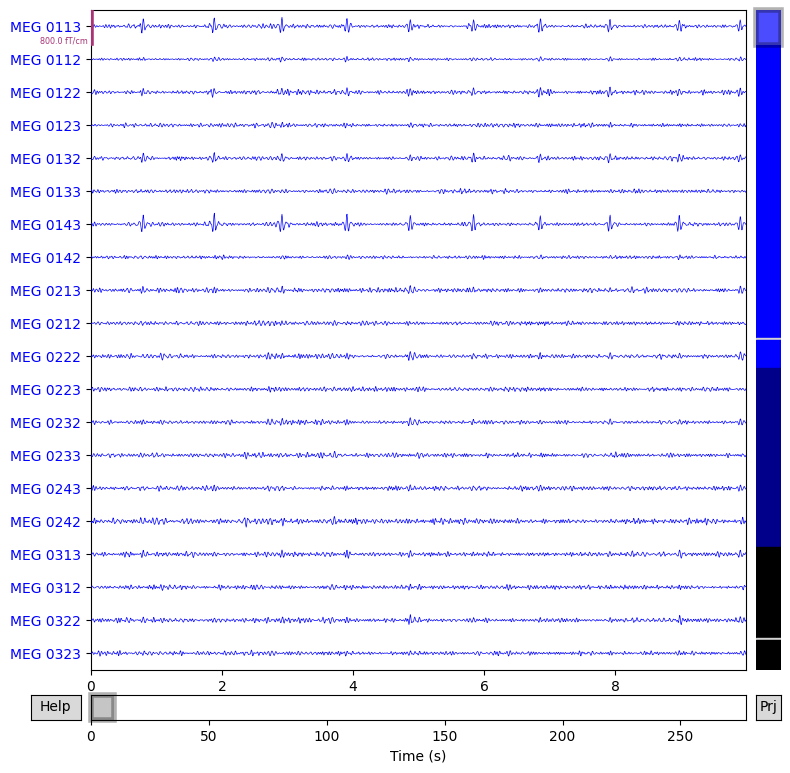

In [42]:
raw_beta.plot()

In [ ]:
raw_beta.filter?

Signature:
raw_beta.filter(
    l_freq,
    h_freq,
    picks=None,
    filter_length='auto',
    l_trans_bandwidth='auto',
    h_trans_bandwidth='auto',
    n_jobs=None,
    method='fir',
    iir_params=None,
    phase='zero',
    fir_window='hamming',
    fir_design='firwin',
    skip_by_annotation=('edge', 'bad_acq_skip'),
    pad='reflect_limited',
    verbose=None,
)
Docstring:
Filter a subset of channels/vertices.

Parameters
----------

l_freq : float | None
    For FIR filters, the lower pass-band edge; for IIR filters, the lower
    cutoff frequency. If None the data are only low-passed.

h_freq : float | None
    For FIR filters, the upper pass-band edge; for IIR filters, the upper
    cutoff frequency. If None the data are only high-passed.
picks : str | array-like | slice | None
    Channels to include. Slices and lists of integers will be interpreted as 
    channel indices. In lists, channel *type* strings (e.g., ``['meg', 
    'eeg']``) will pick channels of those types,

## Exercise
Plot the 10 first seconds of the stimutation channel `STI 014` just using matplotlib.

Tips:

- Find the channel index using `raw.ch_names.index('STI 014')`
- Get the data for this channel
- Plot it using `plt.plot`


# Define and read epochs

Let us now see how events are represented and used in MNE.

## First, extract events.
The [`sample`](https://mne.tools/stable/documentation/datasets.html#sample-dataset) dataset includes experimental events recorded on stim channel `STI 014`. The events are parsed from this channel using [`mne.find_events()`](https://mne.tools/stable/generated/mne.find_events.html#mne.find_events) method:

In [43]:
events = mne.find_events(raw, stim_channel='STI 014', verbose=True)
print(events.shape)
print(type(events))

Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
(319, 3)
<class 'numpy.ndarray'>


The function returns a NumPy array where each row represents an event, typically containing the sample number, the value of the trigger channel before the event, and the event ID. Then, print(events.shape) displays the dimensions of this array, which, in your case, is (319, 3), indicating 319 detected events with 3 columns of information each. Finally, print(type(events)) confirms that the events variable is a numpy.ndarray.

LA - 1 - Response to left-ear auditory stimulus \
RA - 2 - Response to right-ear auditory stimulus \
LV - 3 - Response to left visual field stimulus \
RV - 4 - Response to right visual field stimulus \
smiley - 5 - Response to the smiley face \
button - 32 - Response triggered by the button press

In [ ]:
print(events[:5])  # events is a 2d array, (time, previous, trigger)

[[6994    0    2]
 [7086    0    3]
 [7192    0    1]
 [7304    0    4]
 [7413    0    2]]


See [`events`](https://mne.tools/stable/documentation/glossary.html#term-events) for more information.

In [ ]:
len(events[events[:, 2] == 4])

70

In [ ]:
len(events)

319

## Plot events

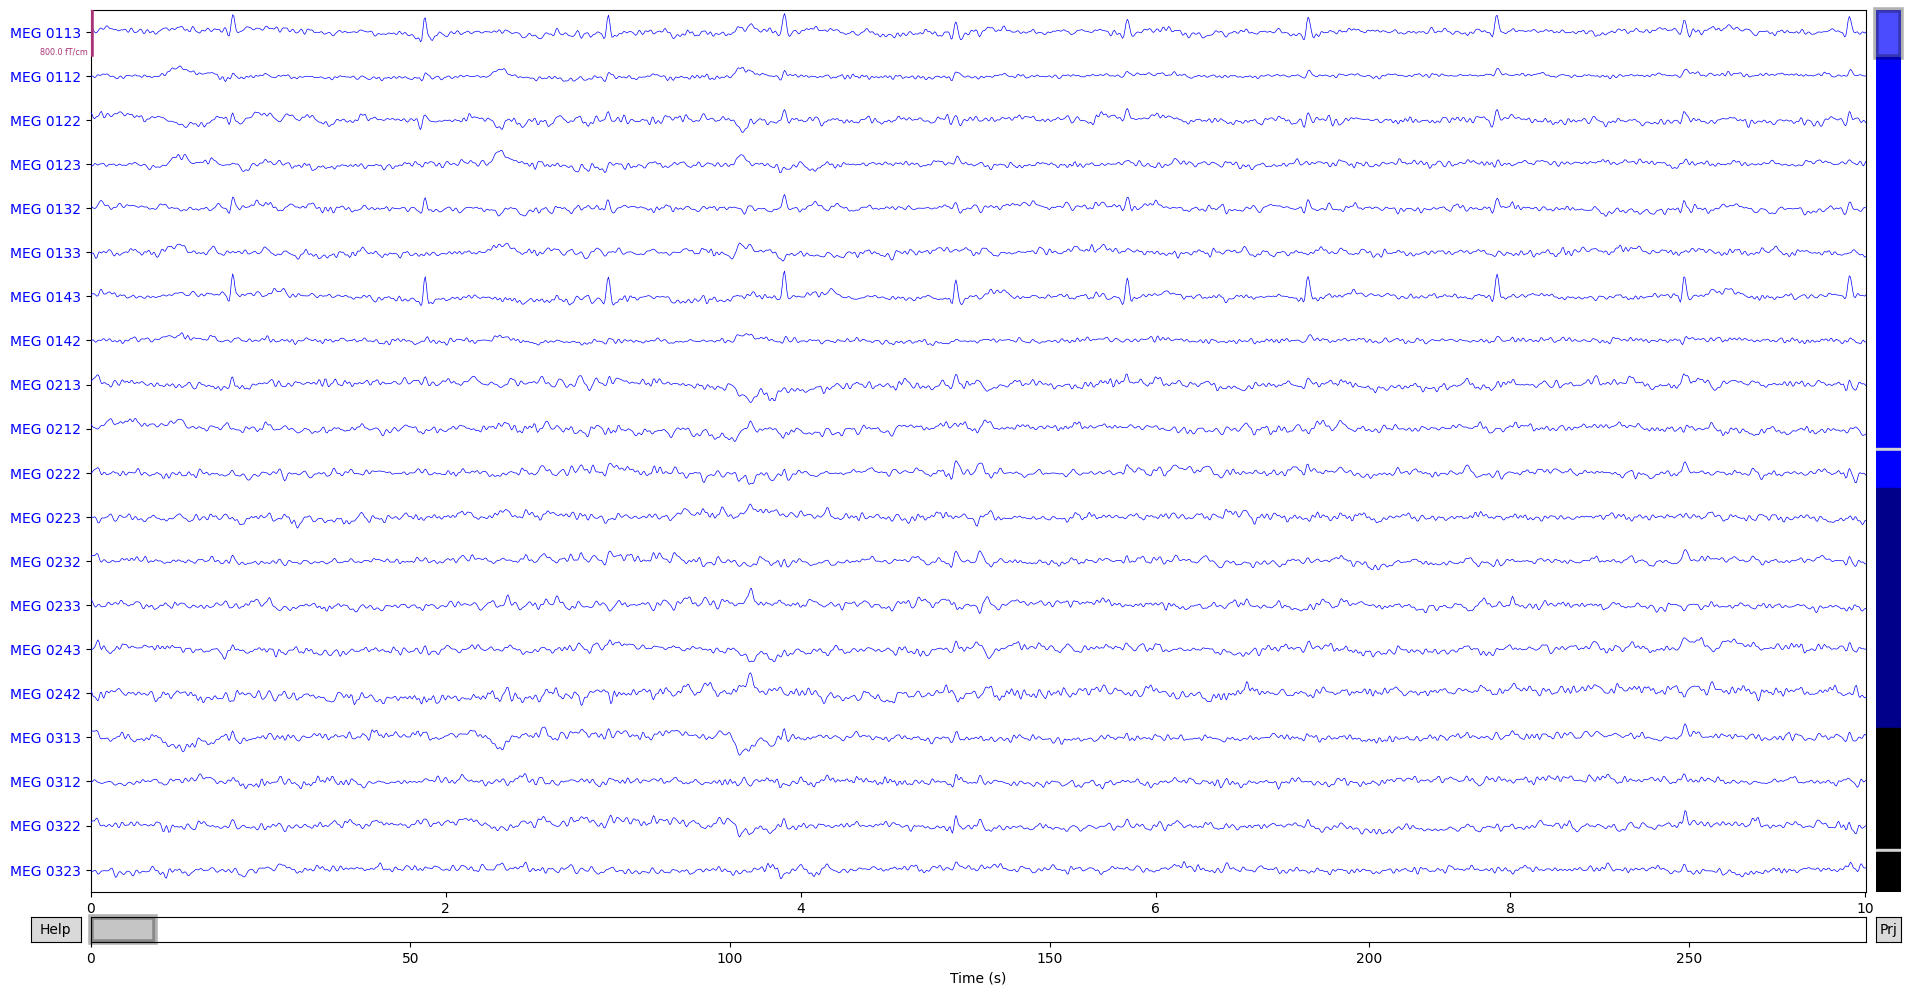

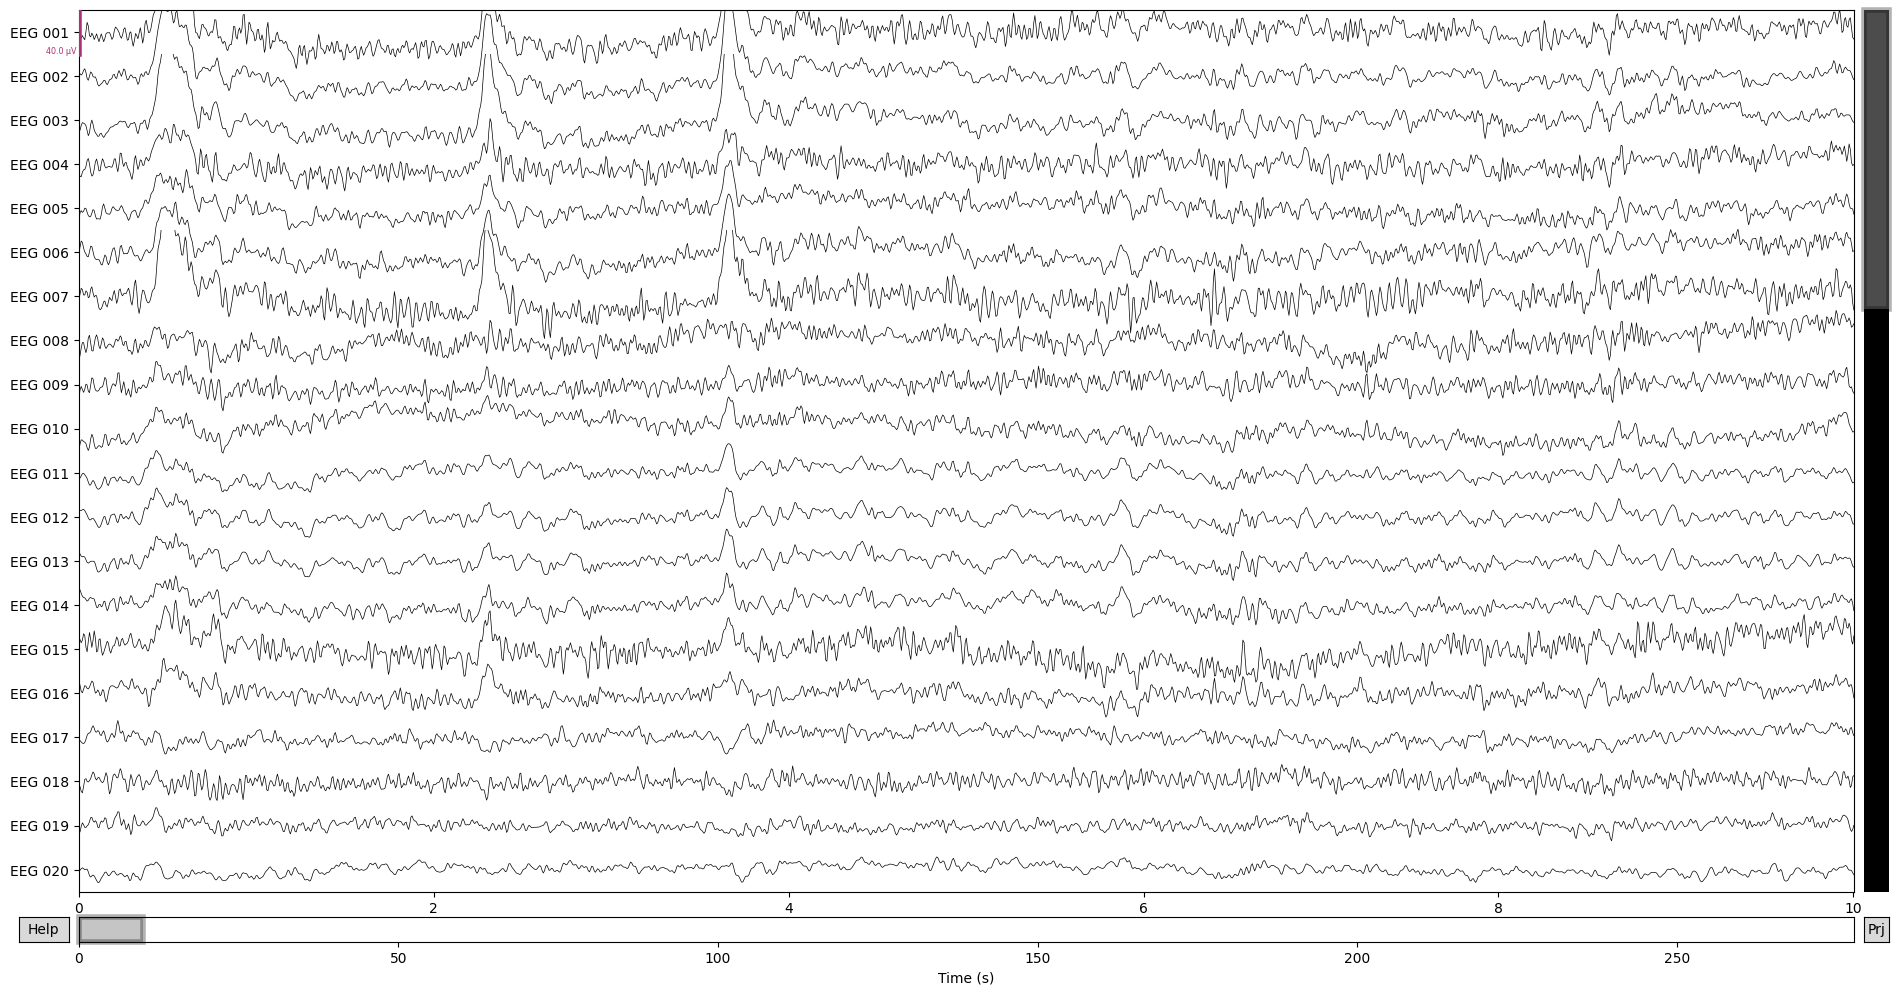

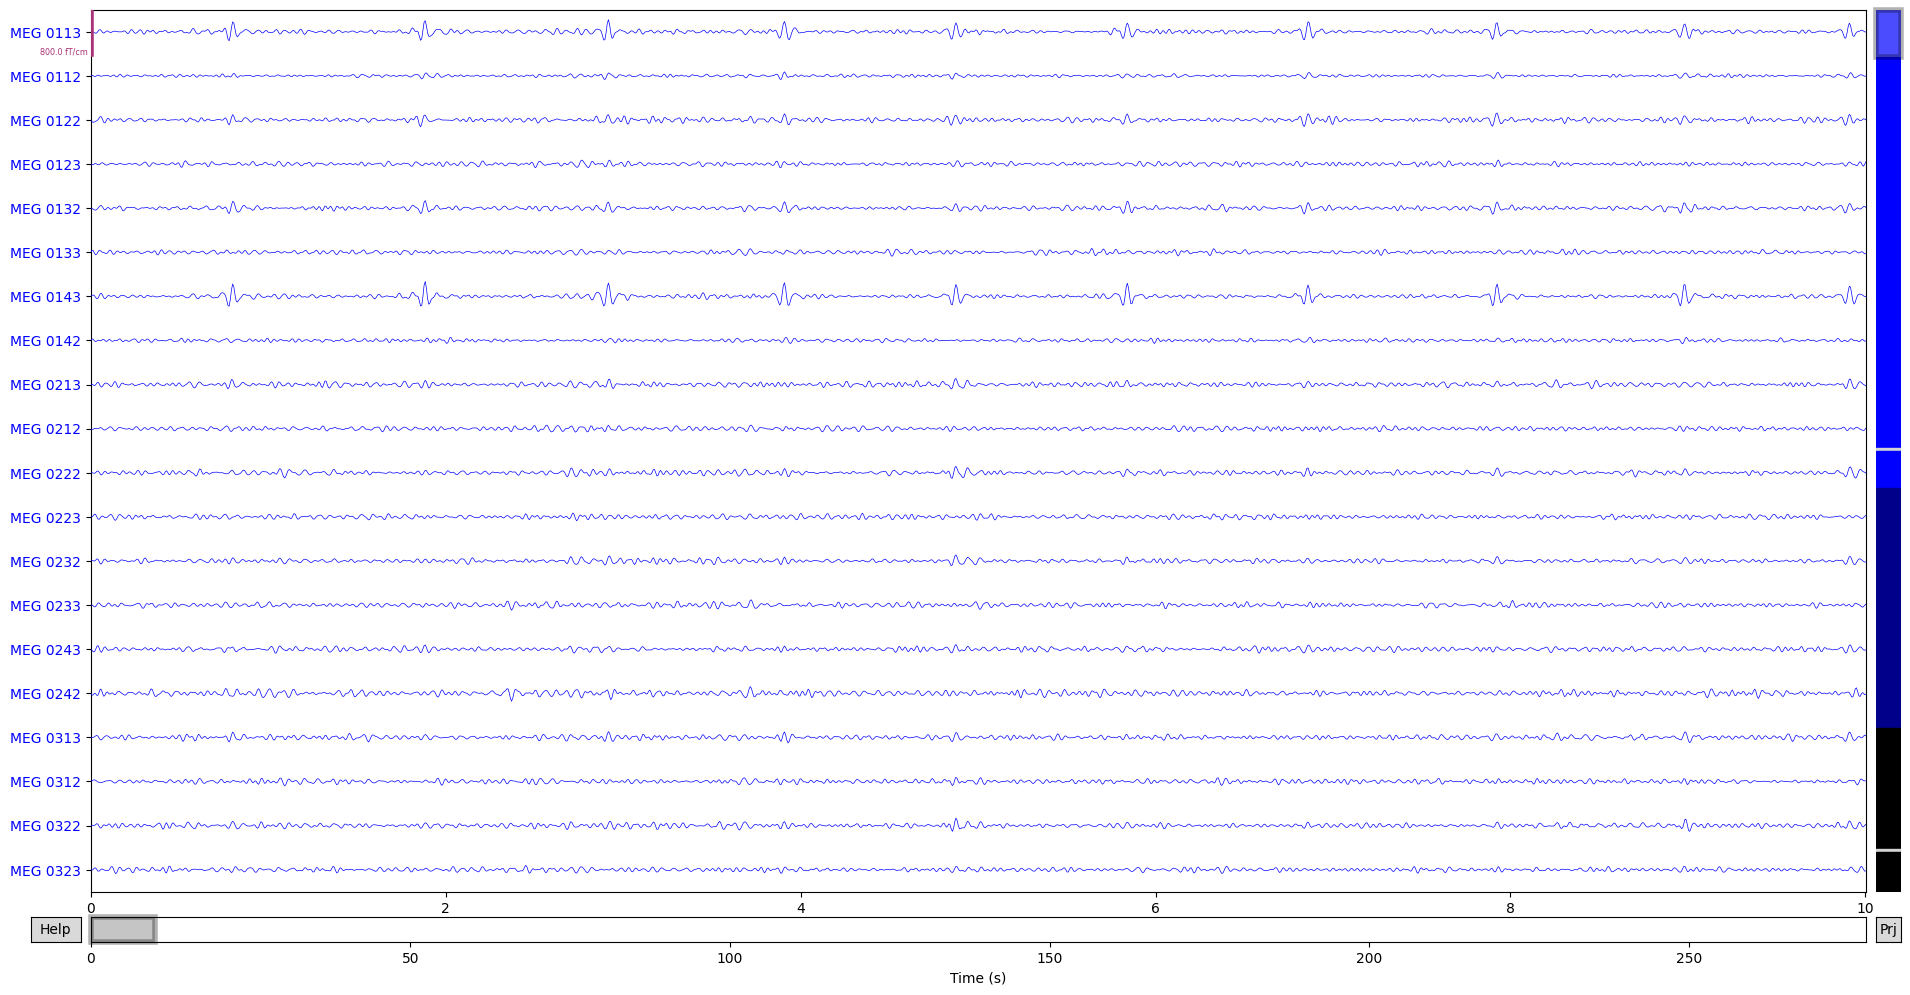

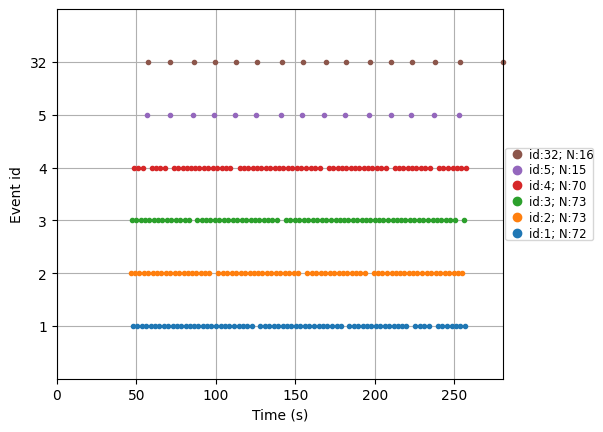

In [ ]:
%matplotlib inline
fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'])

We can create an event Python dictionary to keep track of which Event ID corresponds to which experimental condition. The dictionary will be used to extract epochs from continuous data. The dictionary keys can contain `/` for grouping of sub-conditions. For example, if we want to pool all auditory trials, instead of merging Event IDs 1 and 2 using the `merge_events()` function, we can request for 'auditory' to select all epochs with Event IDs 1 and 2; requesting 'left' trials will select all epochs with Event IDs 1 and 3.


/tmp/ipykernel_26492/4040063837.py:4: RuntimeWarning: event 5 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);
/tmp/ipykernel_26492/4040063837.py:4: RuntimeWarning: event 32 missing from event_id will be ignored
  fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);


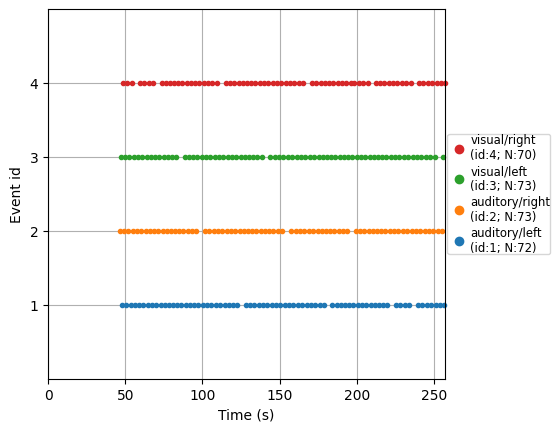

In [ ]:
event_id = {"auditory/left": 1, "auditory/right": 2,
            "visual/left": 3, "visual/right": 4}

fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'], event_id=event_id);

The events can be visualized together with the raw data:

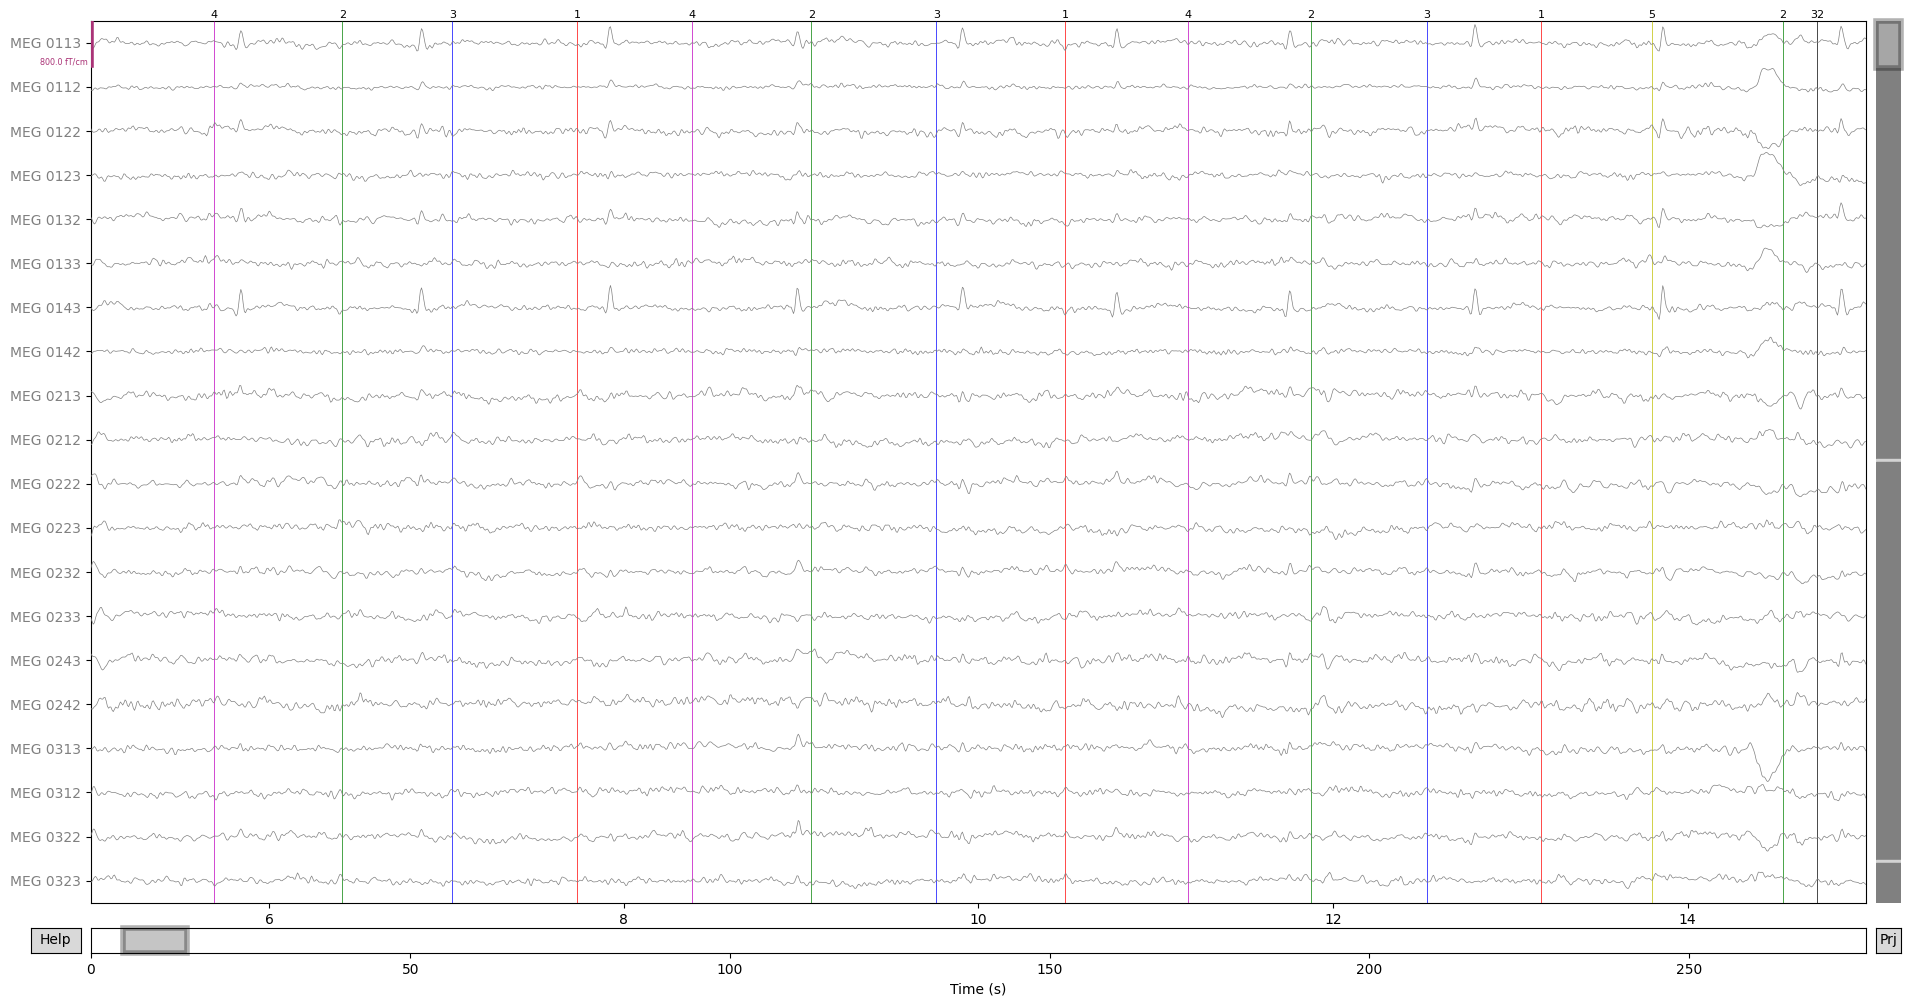

In [ ]:
raw.plot(
    events=events,
    start=5,
    duration=10,
    color="gray",
    event_color={1: "r", 2: "g", 3: "b", 4: "m", 5: "y", 32: "k"},
);

## Create epochs

In MNE-Python [`Epochs`](https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs) objects are a data structure for representing and analyzing equal-duration trials of the M/EEG signal. Epochs are most often used to represent data that is time-locked to repeated experimental events (such as stimulus onsets or subject button presses), but can also be used for storing sequential or overlapping frames of a continuous signal (e.g., for analysis of resting-state activity). \
Inside an Epochs object, the data are stored in an array of shape `(n_epochs, n_channels, n_times)`.

First, define epochs parameters: start, stop, and baseline period of the epochs.

In [ ]:
tmin = -0.2  # start of each epoch (200ms before the trigger)
tmax = 0.5   # end of each epoch (500ms after the trigger)
baseline = (None, 0)  # from the first time instant to the trigger pulse

Define peak-to-peak (amplitude range) rejection parameters for gradiometers, magnetometers, and EOG:

In [ ]:
reject = dict(grad=4000e-13, mag=4e-12, eog=150e-6)  # this can be highly data dependent

In [ ]:
# we select MEG and EOG channels
picks_meg = mne.pick_types(raw.info, meg=True, eeg=False, eog=True,
                           stim=False, exclude='bads')

Extract epochs:

In [ ]:
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True,
                    picks=picks_meg, baseline=baseline,
                    reject=reject)

In [ ]:
print(epochs)

<Epochs | 288 events (good & bad), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~3.2 MiB, data not loaded,
 'auditory/left': 72
 'auditory/right': 73
 'visual/left': 73
 'visual/right': 70>


Remove bad epochs based on the `reject` parameter we passed to `Epochs`.

In [ ]:
epochs.drop_bad()

<Epochs | 239 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~3.2 MiB, data not loaded,
 'auditory/left': 55
 'auditory/right': 61
 'visual/left': 67
 'visual/right': 56>

See how epochs were dropped

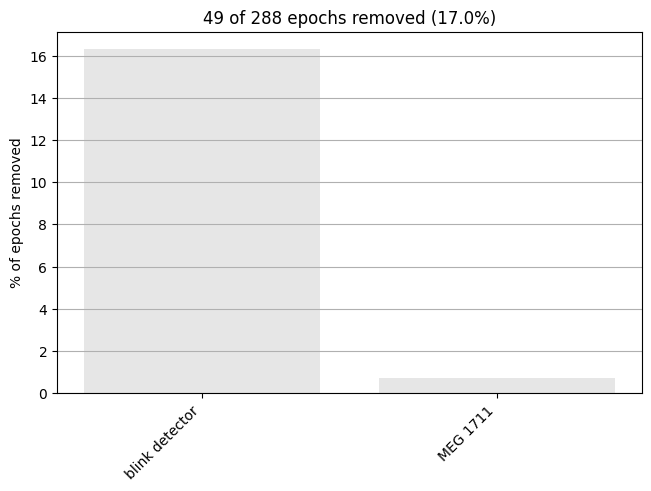

In [ ]:
fig = epochs.plot_drop_log()

To access the data of some epochs use the [`get_data()`](https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.get_data) method.

In [ ]:
epochs_data = epochs.get_data()
type(epochs_data), epochs_data.shape

(numpy.ndarray, (239, 306, 106))

`epochs_data` is a 3D array of dimension n_epochs x n_channels x n_time_points

### Visualization Epochs

See [this page](https://mne.tools/stable/auto_tutorials/epochs/20_visualize_epochs.html) for options on how to visualize epochs. \
The `Epochs` object can be visualized (and browsed interactively) using its [`plot()`](https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.plot) method



In [ ]:
%matplotlib qt

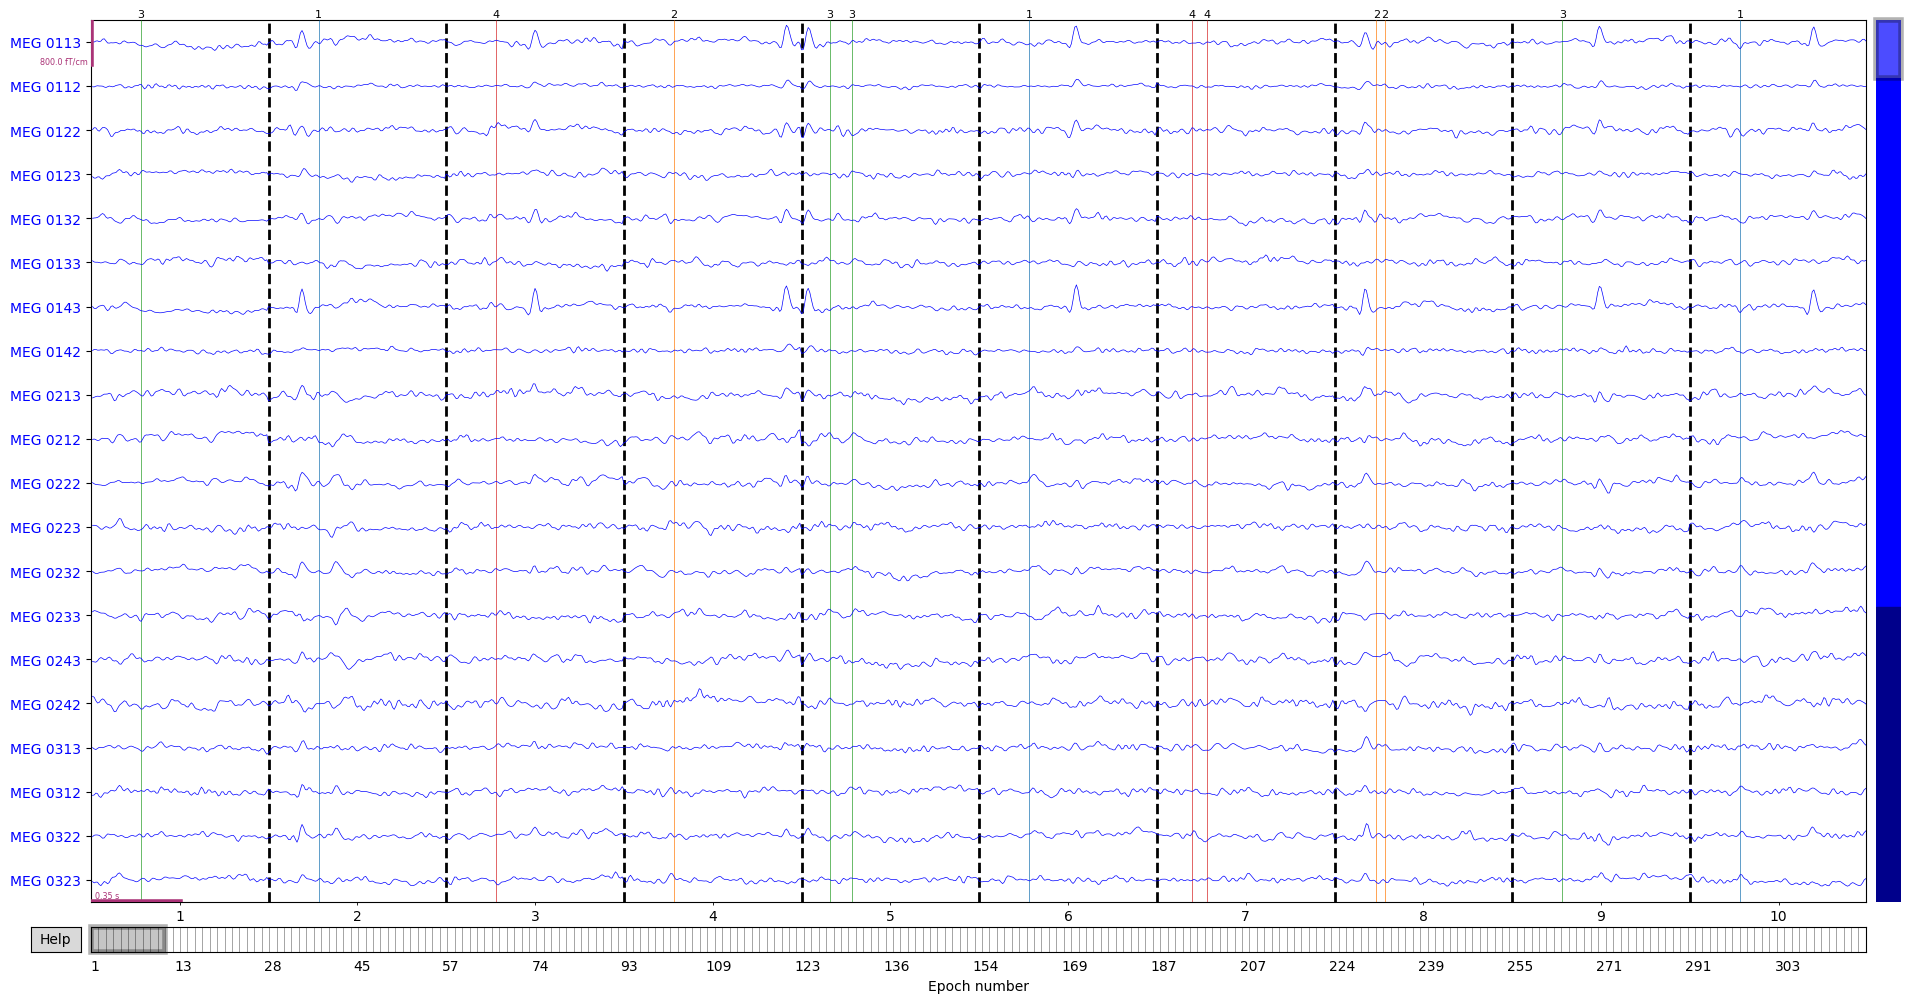

In [ ]:
epochs.plot(n_epochs=10, events=True)

In the plot above we can see heartbeat artifacts in the magnetometer channels, so before we continue let’s load ECG projectors from disk and apply them to the data:

In [ ]:
ecg_proj_file = data_path / "MEG" / "sample" / "sample_audvis_ecg-proj.fif"
ecg_projs = mne.read_proj(ecg_proj_file)
epochs.add_proj(ecg_projs)
epochs.apply_proj()

<Epochs | 239 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~62.4 MiB, data loaded,
 'auditory/left': 55
 'auditory/right': 61
 'visual/left': 67
 'visual/right': 56>

A convenient way to visualize many epochs simultaneously is to plot them as an image map, with each row of pixels in the image representing a single epoch, the horizontal axis representing time, and each pixel’s color representing the signal value at that time sample for that epoch.

In [ ]:
figs = epochs['auditory'].plot_image(combine='mean')

It is also possible to plot spectral power estimates across sensors as a scalp topography

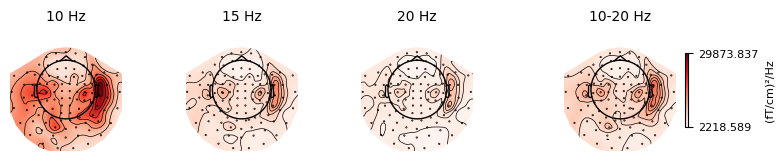

In [ ]:
spectrum = epochs["visual/right"].compute_psd()
bands = {"10 Hz": 10, "15 Hz": 15, "20 Hz": 20, "10-20 Hz": (10, 20)}
spectrum.plot_topomap(bands=bands, vlim="joint", ch_type="grad")

## Average the epochs to get the evoked response (ERF/ERP)

[`Evoked`](https://mne.tools/stable/generated/mne.Evoked.html#mne.Evoked) objects typically store M/EEG signals that have been averaged over multiple epochs, which is a common technique for estimating stimulus-evoked activity. The data in an `Evoked` object are stored in an array of shape `(n_channels, n_times)`. \
We already have the `Epochs` object, so we can simply use its `average` method:

In [ ]:
evoked = epochs.average()
print(evoked)

<Evoked | '0.23 × auditory/left + 0.26 × auditory/right + 0.28 × visual/left + 0.23 × visual/right' (average, N=239), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 305 ch, ~3.5 MiB>


The information about the baseline period of `Epochs` is transferred to derived `Evoked` objects to maintain provenance as you process your data:

In [ ]:
print(f"Epochs baseline: {epochs.baseline}")
print(f"Evoked baseline: {evoked.baseline}")

Epochs baseline: (-0.19979521315838786, 0.0)
Evoked baseline: (-0.19979521315838786, 0.0)


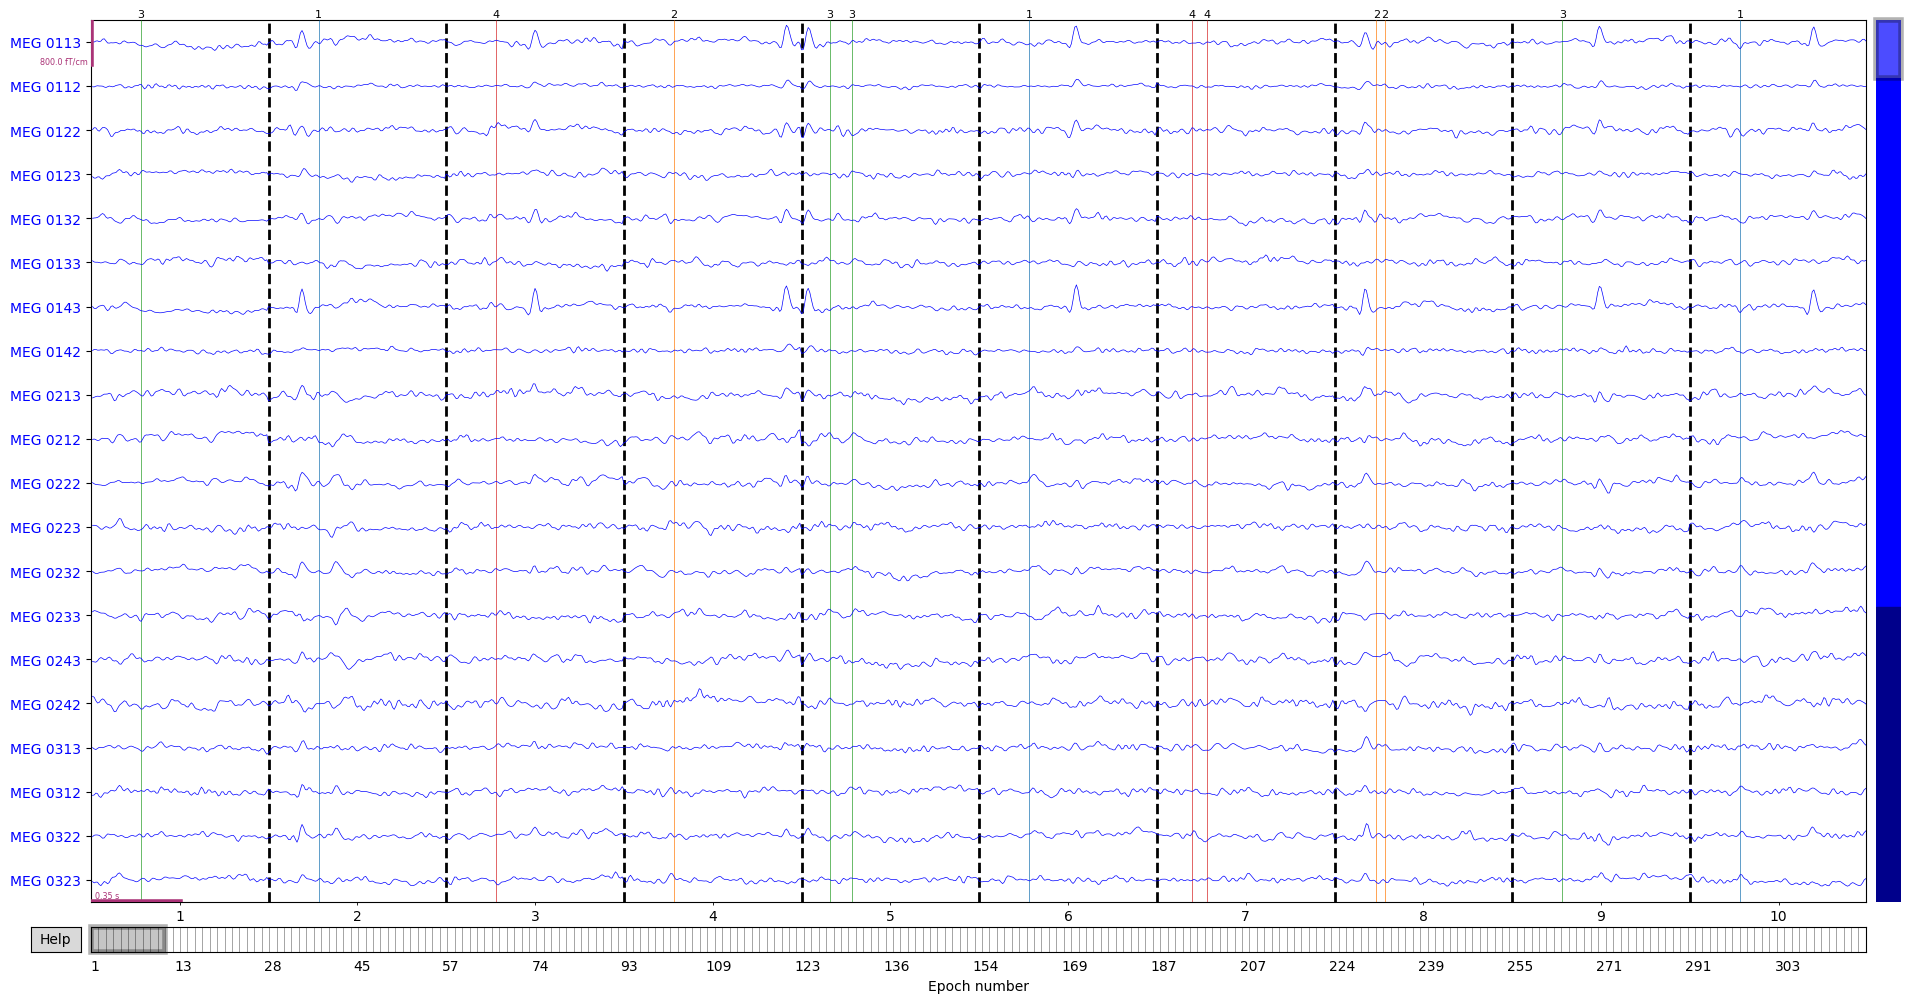

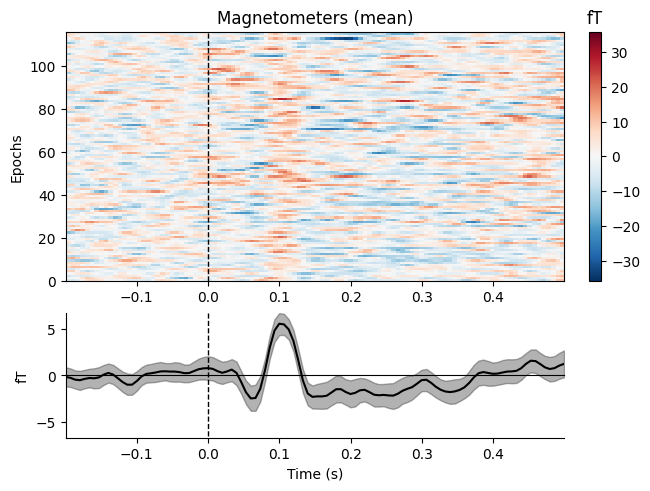

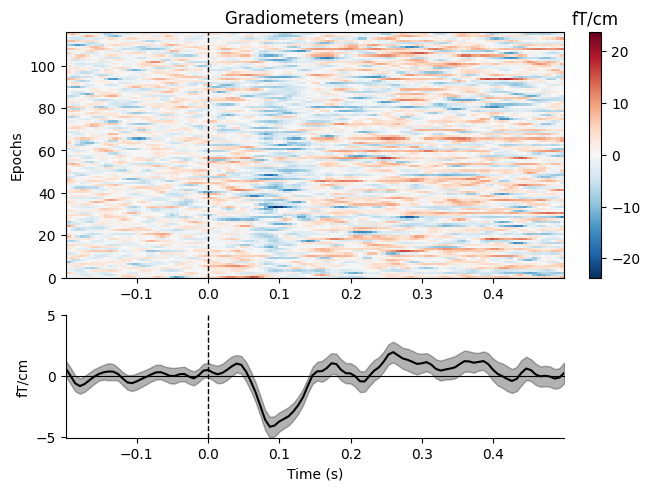

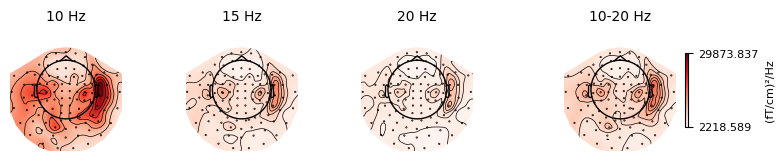

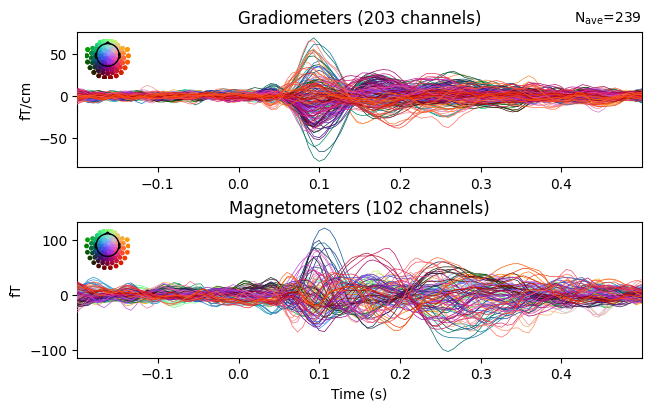

In [ ]:
%matplotlib inline
fig = evoked.plot(spatial_colors=True)

This created an average across **all** conditions. Let's now estimate evoked responses for **individual** conditions.

In [ ]:
print(event_id)

{'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}


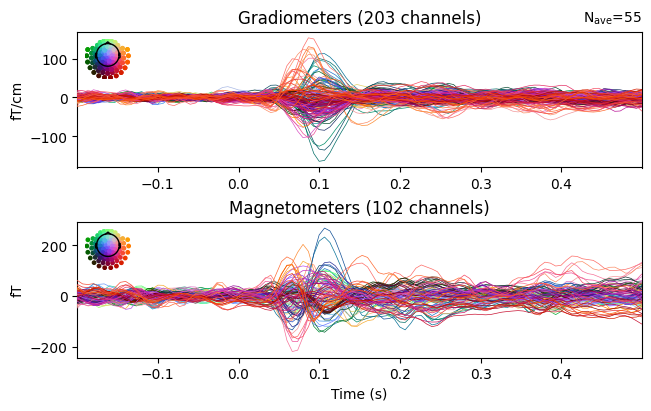

In [ ]:
fig = epochs['auditory/left'].average().plot(spatial_colors=True)

The `plot()` methods for [`Raw`](https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.plot), [`Epochs`](https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.plot) and [`Evoked`](https://mne.tools/stable/generated/mne.Evoked.html#mne.Evoked.plot) objects, has many parameters for customizing the plot output, such as color-coding channel traces by scalp location, or plotting the global field power alongside the channel traces.

## Accessing and indexing epochs by condition

Epochs can be indexed by integers or slices to select a subset of epochs but also with strings to select by conditions `epochs[condition]`

Remember `/` serves as a grouping operator. To calculate the evoked response across **all** "left" stimulations, do the following:

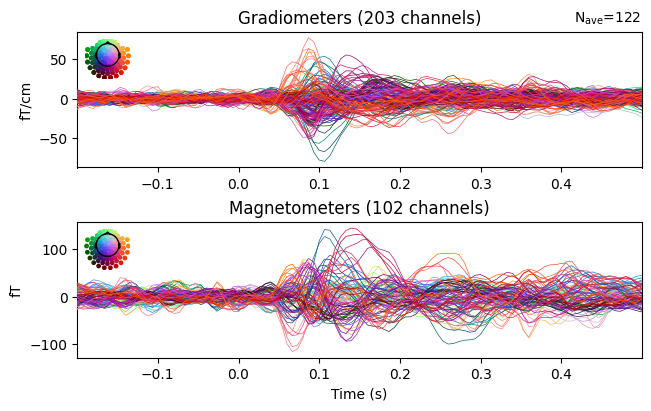

In [ ]:
fig = epochs['left'].average().plot(spatial_colors=True);  # note the legend

In [ ]:
# remember ...
event_id

{'auditory/left': 1, 'auditory/right': 2, 'visual/left': 3, 'visual/right': 4}

In [ ]:
epochs[0]  # first epoch

<Epochs | 1 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~3.5 MiB, data loaded,
 'visual/left': 1>

In [ ]:
epochs[:10]  # first 10 epochs

<Epochs | 10 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~5.7 MiB, data loaded,
 'auditory/left': 3
 'auditory/right': 2
 'visual/left': 3
 'visual/right': 2>

In [ ]:
epochs['visual/left']  # epochs for the left visual condition

<Epochs | 67 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~19.8 MiB, data loaded,
 'visual/left': 67>

In [ ]:
epochs['visual']  # epochs for the visual condition (either left or right)

<Epochs | 123 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~33.7 MiB, data loaded,
 'visual/left': 67
 'visual/right': 56>

In [ ]:
epochs['left']

<Epochs | 122 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~33.4 MiB, data loaded,
 'auditory/left': 55
 'visual/left': 67>

In event_id, `/` selects conditions in a hierarchical way, e.g. here, "auditory" vs. "visual", "left" vs. "right", and MNE can select them individually.

In [ ]:
%matplotlib qt

In [ ]:
evoked_auditory_left = epochs['auditory/left'].average().pick_types(meg='grad')
evoked_auditory_left.crop(None, 0.2) # Beginning of evoked until 0.2s after stimulus onset.
fig = evoked_auditory_left.plot(spatial_colors=True)
fig = evoked_auditory_left.plot(spatial_colors=True, gfp=True)

In the interactive session, the butterfly plots seen above can be click-dragged to select a time region, which will pop up a map of the average field distribution over the scalp for the selected time span.

## Visualize Topographies

The scalp topographies at specific times or time spans can be also generated by using the [`plot_topomap()`](https://mne.tools/stable/generated/mne.Evoked.html#mne.Evoked.plot_topomap) method


In [ ]:
fig = evoked.plot_topomap(ch_type='mag', times=[0.05, 0.1, 0.15])
fig = evoked.plot_topomap(ch_type='grad', times=[0.05, 0.1, 0.15])

In [ ]:
import numpy as np

times = np.linspace(0.05, 0.15, 5)
for ch_type in ('mag', 'grad'):
    fig = evoked.plot_topomap(times=times, ch_type=ch_type)

It is also possible to pass different time durations to average over for each time point. Passing a value of None will disable averaging for that time point:

In [ ]:
averaging_durations = [0.01, 0.02, 0.03, None, None]
fig = evoked.plot_topomap(
    ch_type="mag", times=times, average=averaging_durations
)

[`plot_joint()`](https://mne.tools/stable/generated/mne.Evoked.html#mne.Evoked.plot_joint) combines butterfly plots with scalp topographies, and provide an excellent first-look at evoked data; by default, topographies will be automatically placed based on peak finding.


In [ ]:
figs = evoked.plot_joint()

But of course, you can also specify custom time points for the topomaps.

In [ ]:
figs = evoked.plot_joint(times=[0.1, 0.3])

Let's visualize topomaps for all experimental conditions.

In [ ]:
for condition in event_id:
    fig = epochs[condition].average().plot_topomap(times=[0.1, 0.15])

### Compute a contrast

The function [`combine_evoked()`](https://mne.tools/stable/generated/mne.combine_evoked.html#mne.combine_evoked) computes a weighted sum of the `Evoked` objects given to it. Note that this combines evokeds taking into account the number of averaged epochs (to scale the noise variance)


In [ ]:
evoked_left = epochs['auditory/left'].average()
evoked_right = epochs['auditory/right'].average()

evoked_contrast = mne.combine_evoked([evoked_left, evoked_right], weights=[1, -1])

In [ ]:
fig = evoked_left.plot()
fig = evoked_right.plot()
fig = evoked_contrast.plot()

Plot some topographies:

In [ ]:
vmin, vmax = -4, 4  # Colorbar range
fig = evoked_left.plot_topomap(ch_type='grad')
fig = evoked_right.plot_topomap(ch_type='grad')
fig = evoked_contrast.plot_topomap(ch_type='grad')

/home/hyruuk/GitHub/cocolab/mne_meeg_ml_main/env/lib/python3.10/site-packages/mne/viz/_mpl_figure.py:2355: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(FigureClass=FigureClass, **kwargs)


### EXERCISE
- Extract Epochs restricted to magnetometers on unfiltered data (`sample_audvis_raw.fif`)
- Plot the difference between all *visual* and all *auditory* stimulus presentations
- Recompute everything for EEG

<div class="alert alert-block alert-info">
<b>Note:</b> For more details look at the following tutorials: <br>
    <a href="https://mne.tools/stable/auto_tutorials/raw/index.html" target="_blank">Working with continuous data </a> <br>
    <a href="https://mne.tools/stable/auto_tutorials/epochs/index.html" target="_blank">Segmenting continuous data into epochs</a> <br>
    <a href="https://mne.tools/stable/auto_tutorials/evoked/index.html" target="_blank">Estimating evoked responses</a>
</div>
